<a href="https://colab.research.google.com/github/YRMESHRAM/Machine-Vision-Practical/blob/main/MV_P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import os
import zipfile

# Define paths based on your setup
zip_file_path = '/content/archive (2).zip'
output_dir = '/content/road_signs_data'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Unzip the file
print("Extracting dataset... Please wait.")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Dataset successfully extracted to: {output_dir}")

# Let's see what folders/files are inside to help us choose images
print("Contents of the directory:")
print(os.listdir(output_dir)[:10]) # Shows the first 10 items

Extracting dataset... Please wait.
Dataset successfully extracted to: /content/road_signs_data
Contents of the directory:
['traffic_Data', 'labels.csv']


Images loaded successfully!


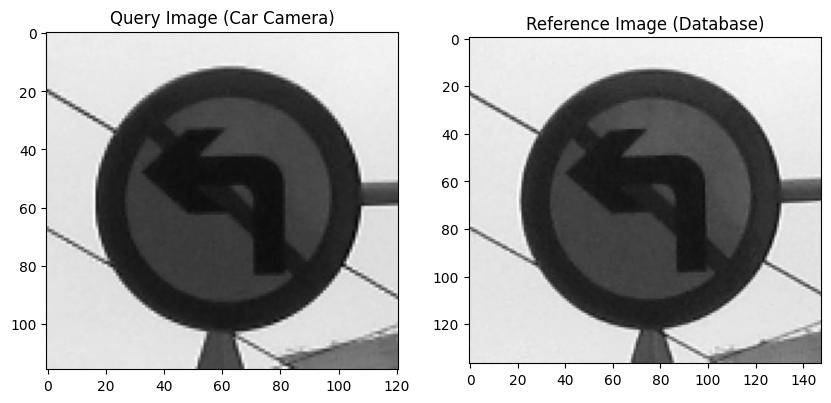

In [24]:
import cv2
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# UPDATE THESE PATHS based on the printed contents from Cell 1!
# 'query_img' is the live photo taken by the car.
# 'reference_img' is the perfect sign from your database.
# -------------------------------------------------------------------------
# Updated to use two images from Class 11 (from the DATA directory) to ensure more matches for homography
query_path = '/content/road_signs_data/traffic_Data/DATA/11/011_1_0009.png'
reference_path = '/content/road_signs_data/traffic_Data/DATA/11/011_0010.png'

# Load images in Grayscale (ORB works best in grayscale)
img_query = cv2.imread(query_path, cv2.IMREAD_GRAYSCALE)
img_reference = cv2.imread(reference_path, cv2.IMREAD_GRAYSCALE)

if img_query is None or img_reference is None:
    print(f"Error: Could not load images. Please check your image file paths!\nQuery Path: {query_path}\nReference Path: {reference_path}")
else:
    print("Images loaded successfully!")

    # Quick side-by-side preview
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_query, cmap='gray')
    axes[0].set_title('Query Image (Car Camera)')
    axes[1].imshow(img_reference, cmap='gray')
    axes[1].set_title('Reference Image (Database)')
    plt.show()

In [21]:
import os

class_11_path = '/content/road_signs_data/traffic_Data/DATA/11/'
if os.path.exists(class_11_path):
    print(f"Contents of {class_11_path}:")
    # List first 20 files to get an idea of naming conventions
    for i, filename in enumerate(os.listdir(class_11_path)):
        if i < 20:
            print(filename)
        else:
            print(f"... ({len(os.listdir(class_11_path)) - 20} more files)")
            break
else:
    print(f"Error: Directory not found at {class_11_path}")

Contents of /content/road_signs_data/traffic_Data/DATA/11/:
011_1_0058.png
011_0059.png
011_0024.png
011_1_0045.png
011_0054.png
011_1_0034.png
011_1_0030.png
011_0010.png
011_0016.png
011_1_0009.png
011_0051.png
011_0009.png
011_0060.png
011_1_0057.png
011_0043.png
011_1_0002.png
011_1_0018.png
011_0026.png
011_0065.png
011_1_0050.png
... (118 more files)


Query Image: Found 18 keypoints.
Reference Image: Found 30 keypoints.


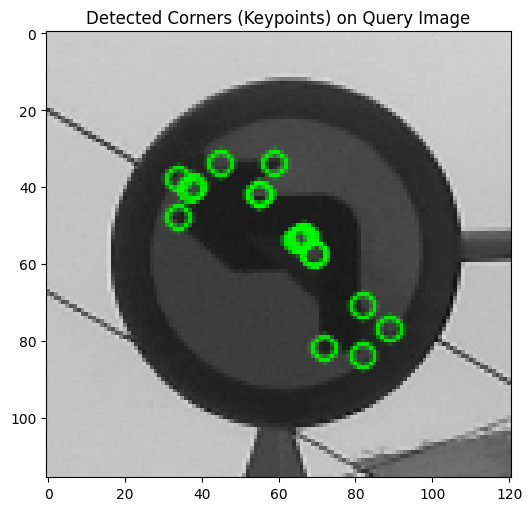

In [25]:
# Initialize the ORB detector (default handles up to 500 keypoints)
orb = cv2.ORB_create(nfeatures=500)

# Step 1 & 2: Find the keypoints (FAST) and compute descriptors (BRIEF)
# kp = keypoints (coordinates of the corners)
# des = descriptors (the binary fingerprints)
kp_query, des_query = orb.detectAndCompute(img_query, None)
kp_reference, des_reference = orb.detectAndCompute(img_reference, None)

print(f"Query Image: Found {len(kp_query)} keypoints.")
print(f"Reference Image: Found {len(kp_reference)} keypoints.")

# Optional Visual: Draw the detected corners on the query image
# Ensure img_query is 3-channel for drawing keypoints if it's grayscale
img_query_display = cv2.cvtColor(img_query, cv2.COLOR_GRAY2BGR) if len(img_query.shape) == 2 else img_query
img_keypoints = cv2.drawKeypoints(img_query_display, kp_query, None, color=(0, 255, 0), flags=0)
plt.figure(figsize=(6, 6))
plt.imshow(img_keypoints)
plt.title("Detected Corners (Keypoints) on Query Image")
plt.show()

FAST Corners in Reference Image : 155
FAST Corners in Test Image      : 107

ORB Keypoints in Reference Image : 30
ORB Keypoints in Test Image      : 18

Total Matches Found : 15


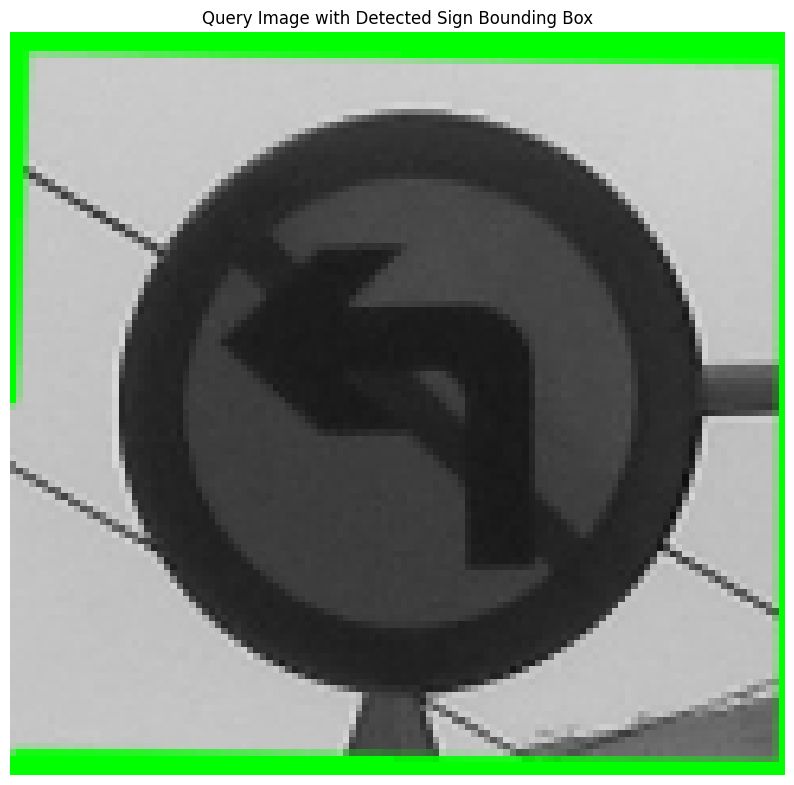

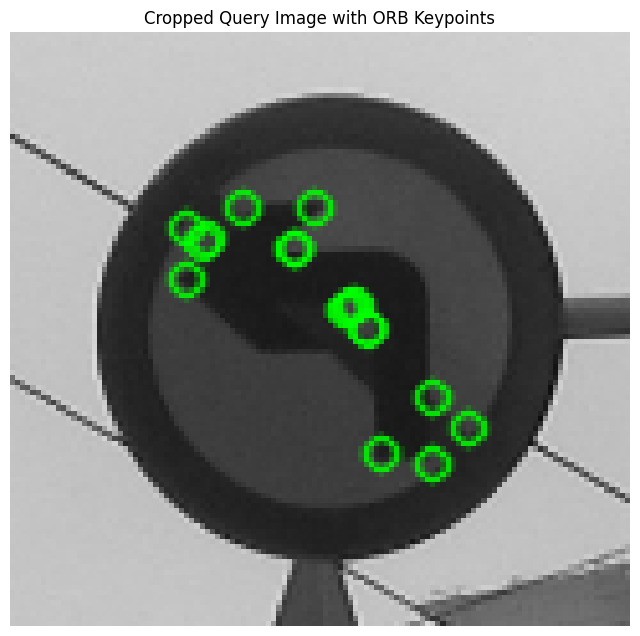

Matching Percentage = 83.33%

First 10 Matched Coordinates

Match 1
Reference Image Coordinate : (108.00000762939453, 90.0)
Test Image Coordinate      : (89.0, 77.0)
Distance                   : 14.0

Match 2
Reference Image Coordinate : (99.60000610351562, 98.4000015258789)
Test Image Coordinate      : (82.0, 84.0)
Distance                   : 15.0

Match 3
Reference Image Coordinate : (99.60000610351562, 82.80000305175781)
Test Image Coordinate      : (82.0, 71.0)
Distance                   : 16.0

Match 4
Reference Image Coordinate : (70.80000305175781, 39.60000228881836)
Test Image Coordinate      : (59.0, 34.0)
Distance                   : 17.0

Match 5
Reference Image Coordinate : (79.20000457763672, 63.36000061035156)
Test Image Coordinate      : (64.80000305175781, 54.000003814697266)
Distance                   : 17.0

Match 6
Reference Image Coordinate : (42.0, 56.400001525878906)
Test Image Coordinate      : (34.0, 48.0)
Distance                   : 18.0

Match 7
Reference Im

In [27]:
import numpy as np

# The images img_query and img_reference are already loaded from previous cells.
# We will use img_reference as img1 (Reference) and img_query as img2 (Test), as per the user's logic.
img1 = img_reference # Reference image
img2 = img_query     # Test image (query image)

# FAST Corner Detection (retained from user's provided code, though not used for ORB matching)
fast = cv2.FastFeatureDetector_create()

fast_kp1 = fast.detect(img1, None)
fast_kp2 = fast.detect(img2, None)

print("FAST Corners in Reference Image :", len(fast_kp1))
print("FAST Corners in Test Image      :", len(fast_kp2))

# ORB Feature Extraction (re-computed as per user's provided code structure)
orb = cv2.ORB_create(nfeatures=1000) # User specified nfeatures=1000

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

print("\nORB Keypoints in Reference Image :", len(kp1))
print("ORB Keypoints in Test Image      :", len(kp2))

# Ensure descriptors are not None and are of proper type for matching
if des1 is None or des2 is None:
    print("Error: Descriptors could not be computed for one or both images. Cannot proceed with matching.")
else:
    # Feature Matching
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    print("\nTotal Matches Found :", len(matches))

    MIN_MATCH_COUNT = 10 # Threshold for reliable homography estimation

    # --- Start of Cropping Logic ---
    cropped_successfully = False
    if len(matches) > MIN_MATCH_COUNT:
        # Extract location of good matches
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in matches ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in matches ]).reshape(-1,1,2)

        # Find Homography (perspective transformation)
        # RANSAC (Random Sample Consensus) is used to filter outliers
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0) # 5.0 is max reprojection error

        if M is not None and M.shape == (3, 3): # Check if homography matrix is valid
            h_ref, w_ref = img1.shape # Dimensions of the reference image
            # Get the four corners of the reference image
            pts = np.float32([[0,0],[0,h_ref-1],[w_ref-1,h_ref-1],[w_ref-1,0]]).reshape(-1,1,2)
            # Transform these corners to the query image perspective using the homography matrix
            dst_corners = cv2.perspectiveTransform(pts, M)

            # Draw bounding box on the original query image for visualization
            img2_display_bbox = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR) # Convert to BGR for color drawing
            img2_display_bbox = cv2.polylines(img2_display_bbox, [np.int32(dst_corners)], True, (0,255,0), 3, cv2.LINE_AA)
            plt.figure(figsize=(10,10))
            plt.imshow(img2_display_bbox)
            plt.title("Query Image with Detected Sign Bounding Box")
            plt.axis('off')
            plt.show()

            # Calculate bounding box coordinates for cropping
            min_x = int(np.min(dst_corners[:,0,0]))
            max_x = int(np.max(dst_corners[:,0,0]))
            min_y = int(np.min(dst_corners[:,0,1]))
            max_y = int(np.max(dst_corners[:,0,1]))

            # Ensure coordinates are within image boundaries
            h_img2, w_img2 = img2.shape
            min_x = max(0, min_x)
            max_x = min(w_img2, max_x)
            min_y = max(0, min_y)
            max_y = min(h_img2, max_y)

            # Check for valid cropping dimensions
            if max_x > min_x and max_y > min_y: # Ensure crop region has positive dimensions
                # Crop the query image
                cropped_img2 = img2[min_y:max_y, min_x:max_x]

                # Filter keypoints to only those within the cropped region
                cropped_kp2 = []
                for kp in kp2:
                    x, y = kp.pt
                    if min_x <= x < max_x and min_y <= y < max_y:
                        # Adjust keypoint coordinates relative to the cropped image
                        # Corrected: Use standard named arguments for cv2.KeyPoint constructor
                        new_kp = cv2.KeyPoint(x=x - min_x, y=y - min_y, size=kp.size, angle=kp.angle,
                                              response=kp.response, octave=kp.octave, class_id=kp.class_id)
                        cropped_kp2.append(new_kp)

                if cropped_img2.size > 0: # Check if cropped image is not empty after cropping
                    # Draw keypoints on the cropped image
                    cropped_img2_display = cv2.drawKeypoints(cv2.cvtColor(cropped_img2, cv2.COLOR_GRAY2BGR), cropped_kp2, None, color=(0, 255, 0), flags=0)
                    plt.figure(figsize=(8,8))
                    plt.imshow(cropped_img2_display)
                    plt.title("Cropped Query Image with ORB Keypoints")
                    plt.axis('off')
                    plt.show()
                    cropped_successfully = True
                else:
                    print("Warning: Cropped image is empty, likely due to small or invalid bounding box.")
            else:
                print(f"Warning: Invalid crop dimensions: min_x={min_x}, max_x={max_x}, min_y={min_y}, max_y={max_y}. Cannot crop.")
        else:
            print("Homography could not be computed or is invalid, cannot crop based on transformation.")
    else:
        print(f"Not enough matches ({len(matches)}) to reliably compute homography (need at least {MIN_MATCH_COUNT}). Skipping cropping.")
    # --- End of Cropping Logic ---

    # Matching Percentage (always calculate and print)
    if len(kp1) > 0 and len(kp2) > 0:
        max_possible = min(len(kp1), len(kp2))
        match_percentage = (len(matches) / max_possible) * 100
    else:
        match_percentage = 0.0
        print("Warning: Cannot calculate matching percentage, one or both images have no keypoints.")
    print("Matching Percentage = {:.2f}%".format(match_percentage))

    # Display First 10 Matched Coordinates
    print("\nFirst 10 Matched Coordinates")
    if matches:
        for i, m in enumerate(matches[:10]):
            pt1 = kp1[m.queryIdx].pt
            pt2 = kp2[m.trainIdx].pt
            print(f"\nMatch {i+1}")
            print("Reference Image Coordinate :", pt1)
            print("Test Image Coordinate      :", pt2)
            print("Distance                   :", round(m.distance,2))
    else:
        print("No matches to display.")

    # Draw Matches (Only if cropping wasn't done, or for a full overview if desired)
    if not cropped_successfully and len(matches) > 0:
        plt.figure(figsize=(15, 8))
        result_all_matches = cv2.drawMatches(
            img1,
            kp1,
            img2,
            kp2,
            matches[:50], # Draw top 50 matches or fewer if less than 50
            None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )
        plt.imshow(result_all_matches)
        plt.title("Top Feature Matches Between Camera and Database Sign (Full Image)")
        plt.axis('off')
        plt.show()
    elif len(matches) == 0 and not cropped_successfully:
        print("No matches to draw (and cropping was not performed).")

    # Recognition Decision
    print("\nRecognition Result")
    if match_percentage > 60:
        print("Very Strong Match")
    elif match_percentage > 40:
        print("Good Match")
    elif match_percentage > 20:
        print("Partial Match")
    else:
        print("Weak Match")